In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pandas as pd

/bin/bash: pip: command not found


ModuleNotFoundError: No module named 'pandas'

In [4]:
# Load accept-reject and hadron data at (a = 0.72, b = 0.88, sigma = 0.335, N = 1e4) 
# accept_reject_monash_prime_PATH = './posthoc_data/pgun_qqbar_mT2_accept_reject_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
accept_reject_monash_prime_PATH = '/global/homes/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_a_0.72_b_0.88_sigma_0.335_N_1.0e+04_id_mT2_accept_reject_z.npy'
pgun_accept_reject_monash_prime = np.load(accept_reject_monash_prime_PATH, mmap_mode = "r")

# fPrel_monash_prime_PATH = './posthoc_data/pgun_qqbar_fPrel_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
fPrel_monash_prime_PATH = '/global/homes/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_a_0.72_b_0.88_sigma_0.335_N_1.0e+04_fPrel.npy'
pgun_fPrel_monash_prime = np.load(fPrel_monash_prime_PATH, mmap_mode = "r")

# filename_hadrons_monash_prime = './posthoc_data/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
filename_hadrons_monash_prime = '/global/homes/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_a_0.72_b_0.88_sigma_0.335_N_1.0e+04_hadrons.npy'
pgun_hadrons_monash_prime = np.load(filename_hadrons_monash_prime, mmap_mode="r")

# Load the hadron data from Monash for comparison (a = 0.68, b = 0.98, sigma = 0.335, N = 1e4)
# filename_hadrons_monash = './posthoc_data/pgun_qqbar_hadrons_a_0.68_b_0.98_sigma_0.335_N_1e4.npy'
filename_hadrons_monash = '/global/homes/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_a_0.71_b_0.88_sigma_0.335_N_1.0e+03_hadrons.npy'
pgun_hadrons_monash = np.load(filename_hadrons_monash, mmap_mode="r")

In [5]:
# Check the shapes
print("Accepted and rejected z data shape (Monash'):", pgun_accept_reject_monash_prime.shape)
print("Hadron data shape (Monash'):", pgun_hadrons_monash_prime.shape)

Accepted and rejected z data shape (Monash'): (10000, 162, 103)
Hadron data shape (Monash'): (10000, 75, 5)


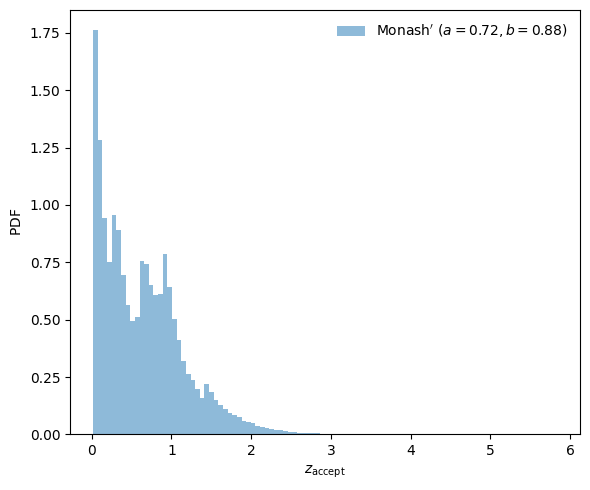

In [15]:
# Histrogram accepted z-values across all events
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.hist(pgun_accept_reject_monash_prime[:,:,2][pgun_accept_reject_monash_prime[:,:,2] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Monash'}$ $(a = 0.72, b = 0.88)$")
ax.set_xlabel(r'$z_{\mathrm{accept}}$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.legend(frameon = False)
fig.tight_layout()

In [28]:
ids_old = pgun_accept_reject_monash_prime[:,:,0][pgun_accept_reject_monash_prime[:,:,0] > 0.0]
ids_new = pgun_accept_reject_monash_prime[:,:,1][pgun_accept_reject_monash_prime[:,:,1] > 0.0]
print(ids_old.shape)
particles, counts = np.unique(ids_old, return_counts=True)
# particles = np.array(unique_values,dtype=int)
particles = [int(p) for p in particles]
print(particles)
print(counts)
particle_types = {}
for i in range(len(particles)):
    particle_types[particles[i]] = counts[i]

paticle_types = {k: int(v) for k, v in particle_types.items()}
print(pd.Dataframe(particle_types))



(97754,)
[1, 2, 3, 1103, 2101, 2103, 2203, 3101, 3103, 3201, 3203, 3303]
[34545 50170  7414   243  3550   273   302   543    55   602    49     8]


NameError: name 'pd' is not defined

In [10]:
Nevent = 10000
# Collect multiplicity data
# mult_monash = np.array([len(pgun_hadrons_monash[i,:][np.abs(pgun_hadrons_monash[i,:,0]) > 0.0]) for i in range(Nevent)])
mult_monash_prime = np.array([len(pgun_hadrons_monash_prime[i,:][np.abs(pgun_hadrons_monash_prime[i,:,0]) > 0.0]) for i in range(Nevent)])

print(mult_monash_prime.shape)

(10000,)


3.0 23.0


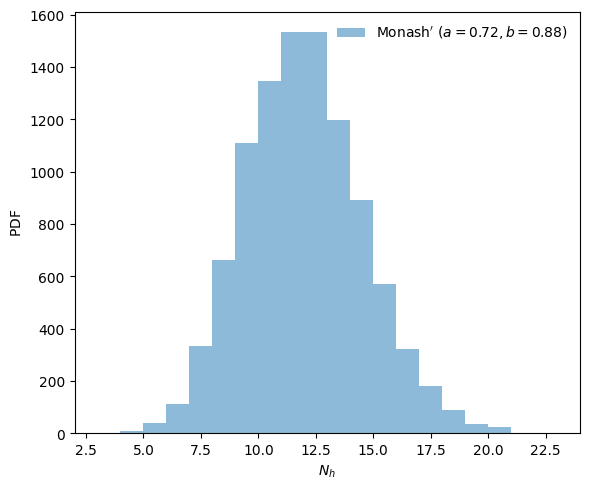

In [12]:
# Histrogram hadron multiplicity
fig, ax = plt.subplots(1,1,figsize=(6,5))

# _, bins_monash = np.histogram(mult_monash)
_, bins_monash_prime = np.histogram(mult_monash_prime)

# min_monash, max_monash = bins_monash[0], bins_monash[-1]
min_monash_prime, max_monash_prime = bins_monash_prime[0], bins_monash_prime[-1]

# print(min_monash, max_monash)
print(min_monash_prime, max_monash_prime)

# min = np.min([min_monash, min_monash_prime])
# max = np.max([max_monash, max_monash_prime])
min, max = min_monash_prime, max_monash_prime

bins = np.linspace(min, max, int((max - min)+1))

# counts, _, _ = ax.hist(mult_monash, bins, alpha = 0.5, density = False, label = r'$\mathrm{Monash}$ $(a = 0.68, b = 0.98)$')
counts, _, _ = ax.hist(mult_monash_prime, bins = bins, alpha = 0.5, density = False, label = r"$\mathrm{Monash'}$ $(a = 0.72, b = 0.88)$")
ax.set_xlabel(r'$N_h$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.legend(frameon = False)
fig.tight_layout()